Import the libraries

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Preprocessing

In [ ]:

df = pd.read_csv("/content/sample_data/bank_transactions_data_2.csv")
df.head()


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [ ]:
print(df.isnull().sum())

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64


In [ ]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

In [ ]:
df['TransactionHour'] = df['TransactionDate'].dt.hour
df['TransactionDay'] = df['TransactionDate'].dt.day
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['TransactionDayOfWeek'] = df['TransactionDate'].dt.dayofweek

In [ ]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionHour,TransactionDay,TransactionMonth,TransactionDayOfWeek
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08,16,11,4,1
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,16,27,6,1
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,18,10,7,0
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06,16,5,5,4
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39,17,16,10,0


Exploratory data analysis - **EDA**

---Distribution of Transaction

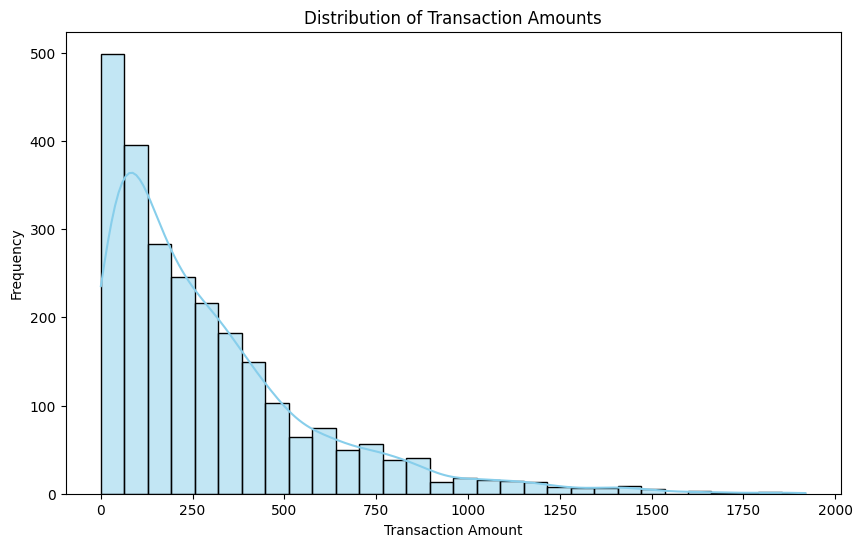

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TransactionAmount'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

---Transaction Type

<ipython-input-14-a81750156720>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='TransactionType', palette='viridis')


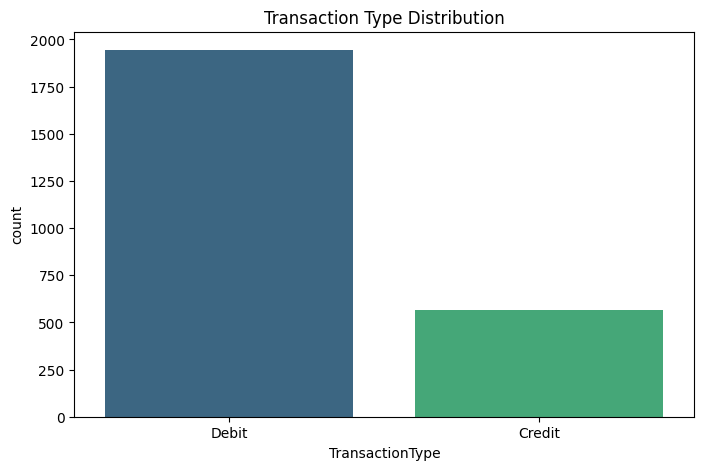

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='TransactionType', palette='viridis')
plt.title("Transaction Type Distribution")
plt.show()

Amount Distribution

<ipython-input-15-354ae2169bbf>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


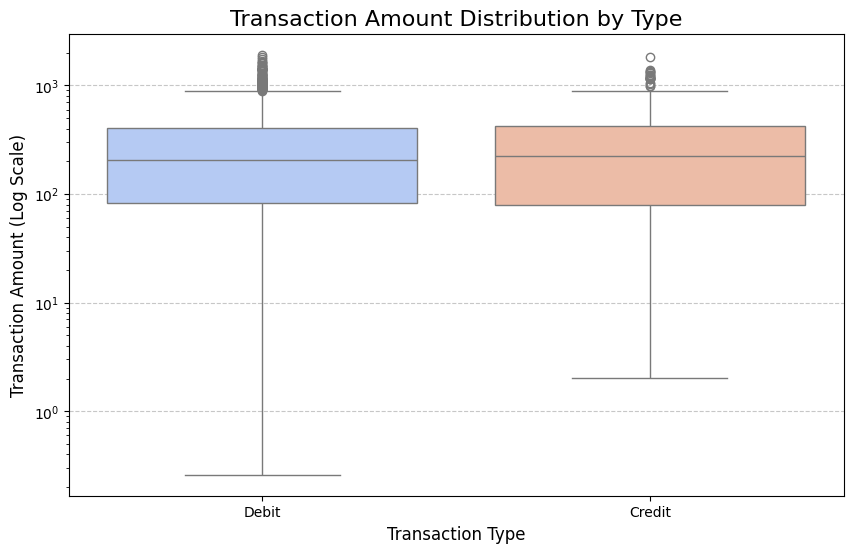

In [ ]:
plt.figure(figsize=(10, 6))  # Set figure size
sns.boxplot(
    data=df,
    x='TransactionType',
    y='TransactionAmount',
    palette='coolwarm'
)

plt.yscale('log')
plt.title("Transaction Amount Distribution by Type", fontsize=16)
plt.xlabel("Transaction Type", fontsize=12)
plt.ylabel("Transaction Amount (Log Scale)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


---Transaction Amount by Age group

<ipython-input-16-5c8834d59702>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='AgeGroup',y='TransactionAmount',palette='coolwarm',showfliers=False


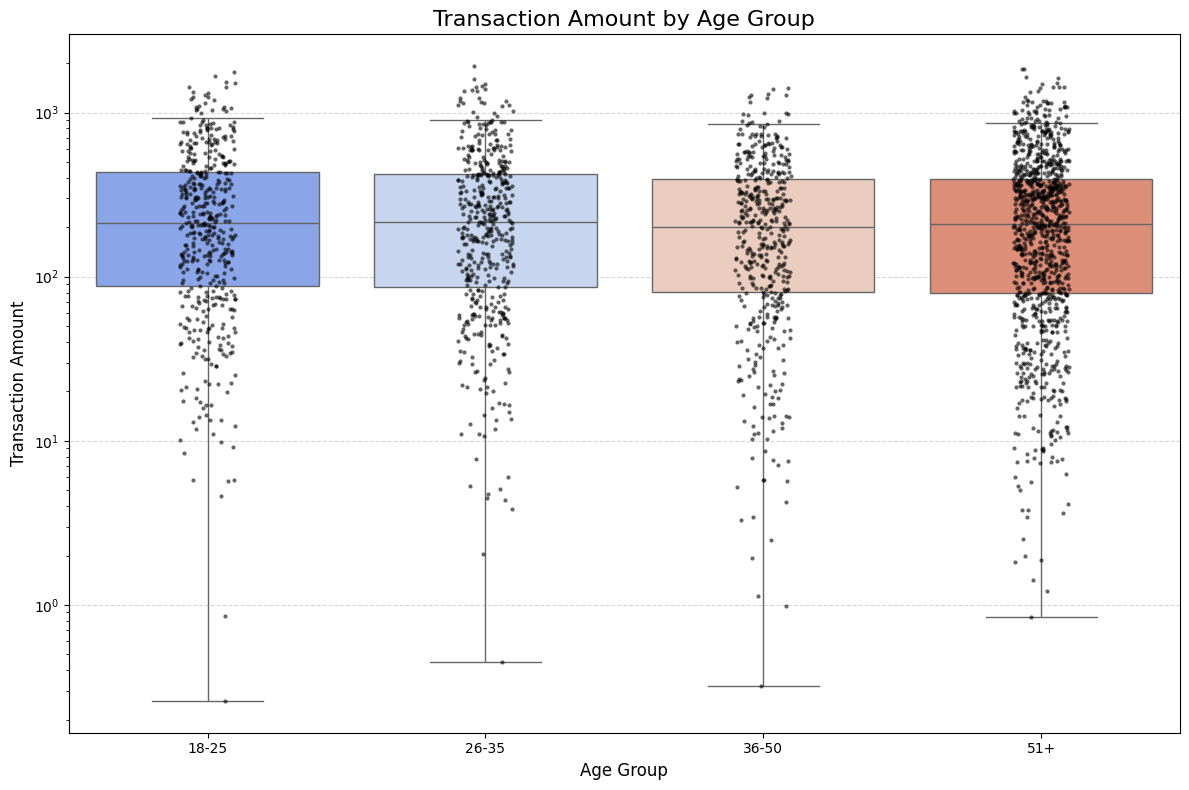

In [ ]:
df['AgeGroup'] = pd.cut(
    df['CustomerAge'],
    bins=[0, 25, 35, 50, 100],
    labels=['18-25', '26-35', '36-50', '51+']
)

plt.figure(figsize=(12, 8))
sns.boxplot(data=df,x='AgeGroup',y='TransactionAmount',palette='coolwarm',showfliers=False
)

sns.stripplot(
    data=df,x='AgeGroup',y='TransactionAmount',color='black',size=3,alpha=0.6,jitter=True
)

plt.title("Transaction Amount by Age Group", fontsize=16)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Transaction Amount", fontsize=12)
plt.yscale("log")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


---No. of Transactions

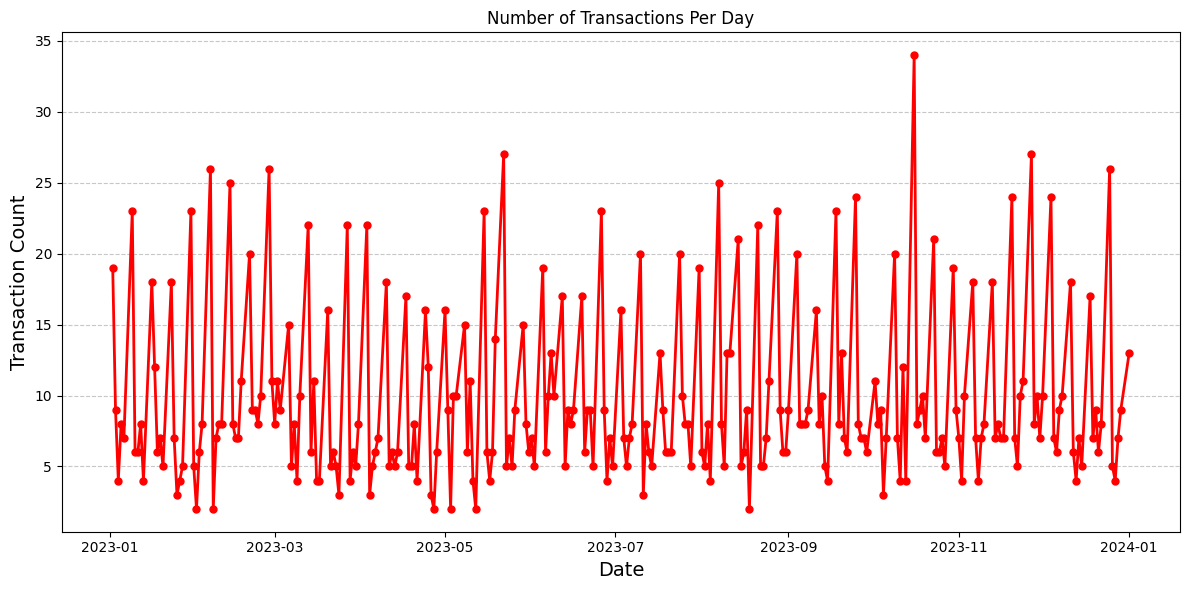

In [ ]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['TransactionDay'] = df['TransactionDate'].dt.date
daily_counts = df.groupby('TransactionDay').size()
plt.figure(figsize=(12, 6))
daily_counts.plot(
    title="Number of Transactions Per Day",
    color='red',
    linewidth=2,
    marker='o',
    markersize=5
)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Transaction Count", fontsize=14)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()


---Transaction count by Day of week

<ipython-input-18-be89a58f1192>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


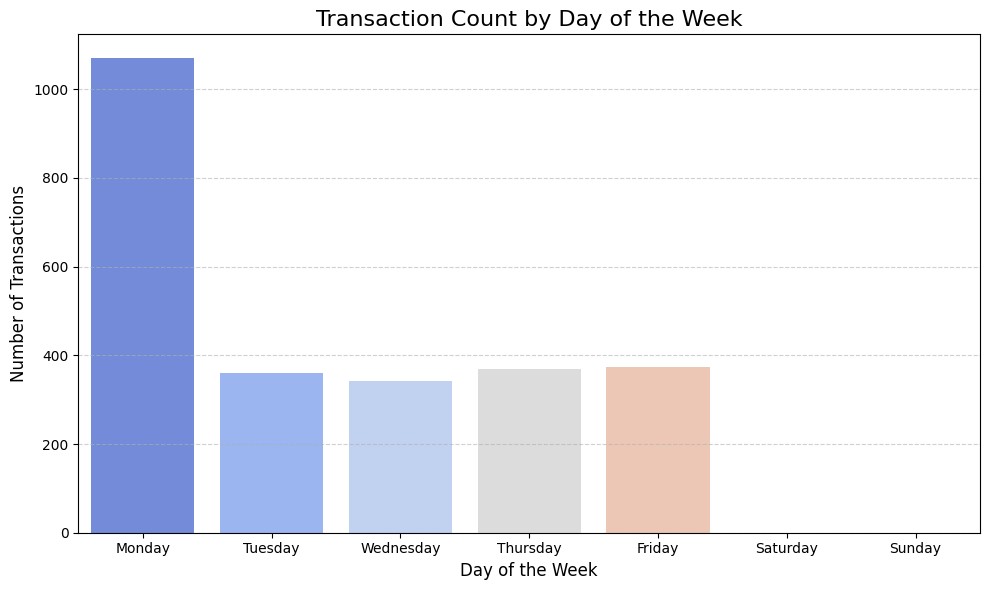

In [ ]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='DayOfWeek',
    order=day_order,
    palette='coolwarm'
)
plt.title('Transaction Count by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()


---Transaction Frequency by hour

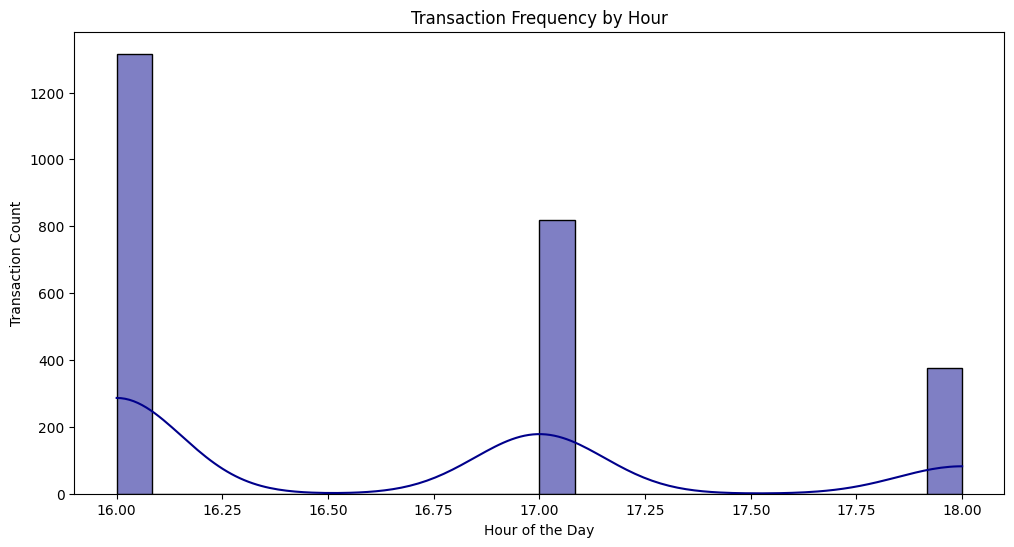

In [ ]:
df['Hour'] = df['TransactionDate'].dt.hour
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Hour', kde=True, bins=24, color='darkblue')
plt.title("Transaction Frequency by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Transaction Count")
plt.show()

---Location Distribution of Transaction

<ipython-input-20-2688894808ad>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


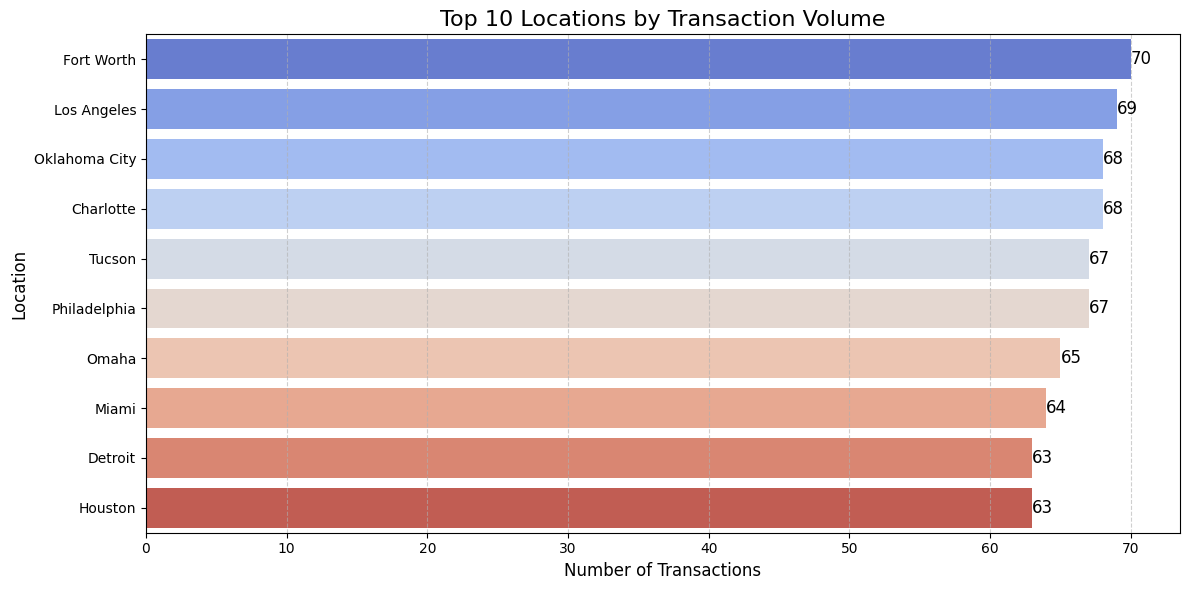

In [ ]:
top_locations = df['Location'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(
    y=top_locations.index,
    x=top_locations.values,
    palette='coolwarm'
)

plt.title('Top 10 Locations by Transaction Volume', fontsize=16)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Location', fontsize=12)
for index, value in enumerate(top_locations.values):
    plt.text(
        value, index,
        str(value),
        color='black',
        ha='left',
        va='center',
        fontsize=12
    )
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


---Customer Age distribution

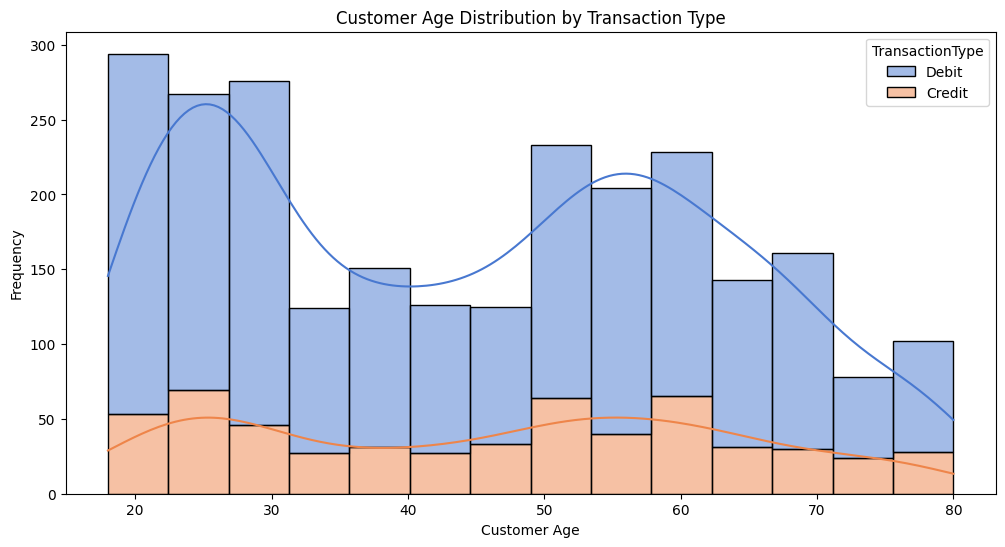

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='CustomerAge', hue='TransactionType', multiple='stack', palette='muted', kde=True)
plt.title('Customer Age Distribution by Transaction Type')
plt.xlabel('Customer Age')
plt.ylabel('Frequency')
plt.show()

---Login Attempts vs Transaction Amount (Potential Fraud Indicator)

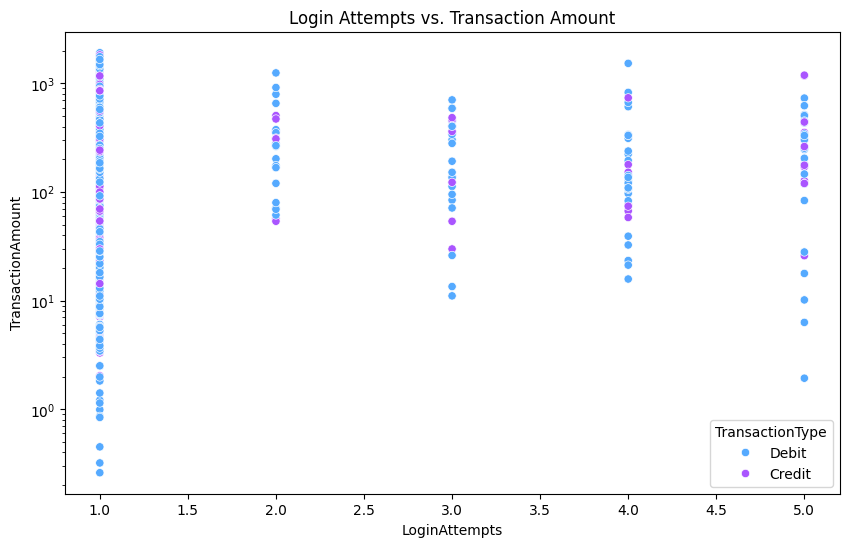

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='LoginAttempts', y='TransactionAmount', hue='TransactionType', palette='cool')
plt.yscale('log')
plt.title("Login Attempts vs. Transaction Amount")
plt.show()

---Time Gap between Transactions

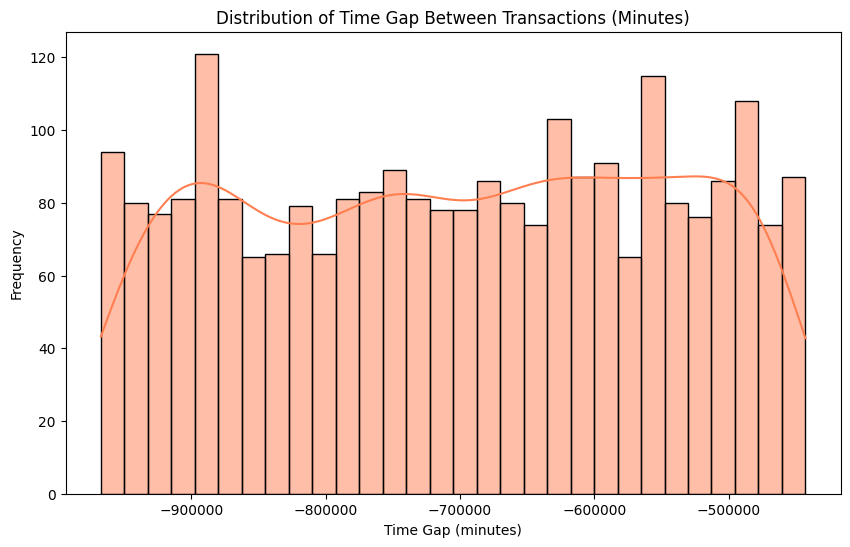

In [ ]:
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])
df['TimeGap'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.total_seconds() / 60
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='TimeGap', bins=30, color='coral', kde=True)
plt.title("Distribution of Time Gap Between Transactions (Minutes)")
plt.xlabel("Time Gap (minutes)")
plt.ylabel("Frequency")
plt.show()

---IP address and its device variations

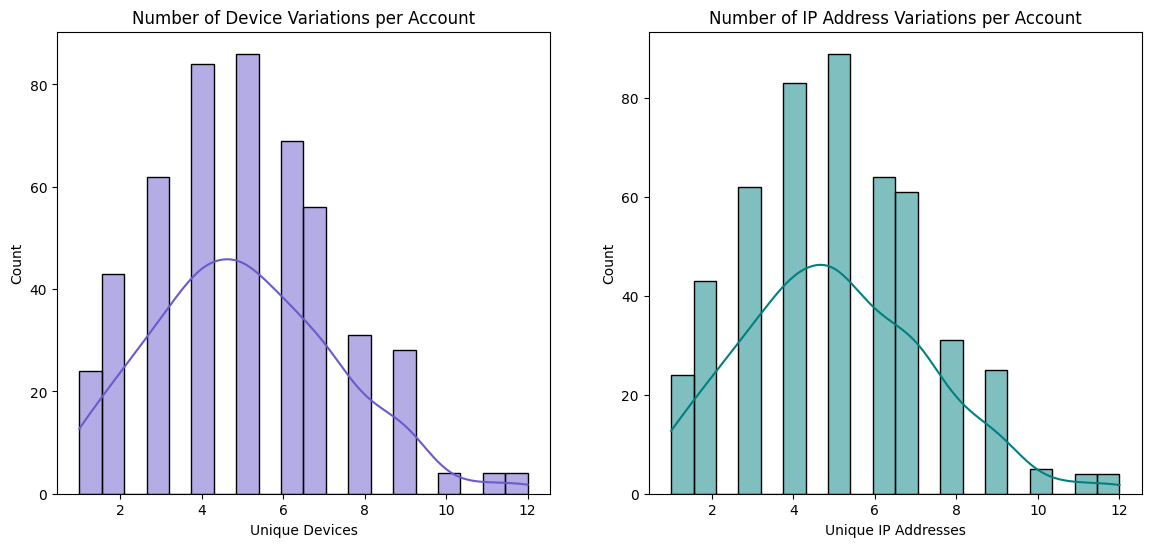

In [ ]:
device_variations = df.groupby('AccountID')['DeviceID'].nunique()
ip_variations = df.groupby('AccountID')['IP Address'].nunique()
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(device_variations, bins=20, color='slateblue', kde=True)
plt.title("Number of Device Variations per Account")
plt.xlabel("Unique Devices")
plt.subplot(1, 2, 2)
sns.histplot(ip_variations, bins=20, color='teal', kde=True)
plt.title("Number of IP Address Variations per Account")
plt.xlabel("Unique IP Addresses")
plt.show()

---Frequent merchants

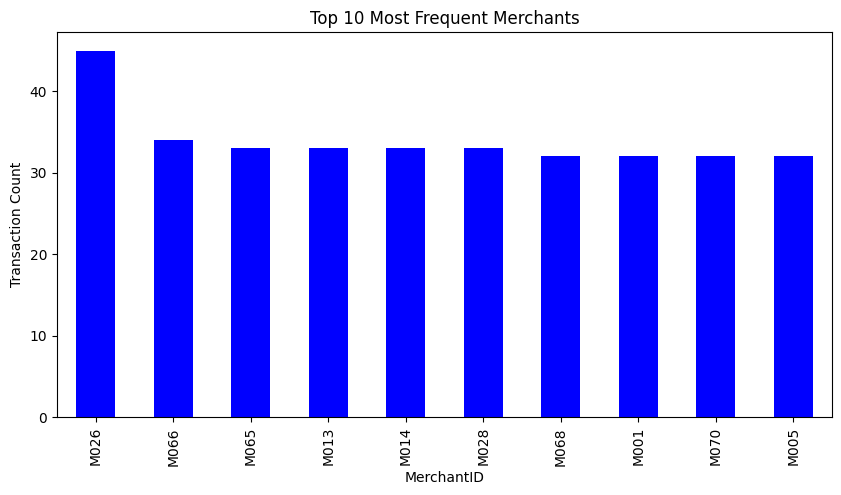

In [ ]:
merchant_counts = df['MerchantID'].value_counts().head(10)
plt.figure(figsize=(10, 5))
merchant_counts.plot(kind='bar', color='blue')
plt.title("Top 10 Most Frequent Merchants")
plt.xlabel("MerchantID")
plt.ylabel("Transaction Count")
plt.show()

K-means Clustering

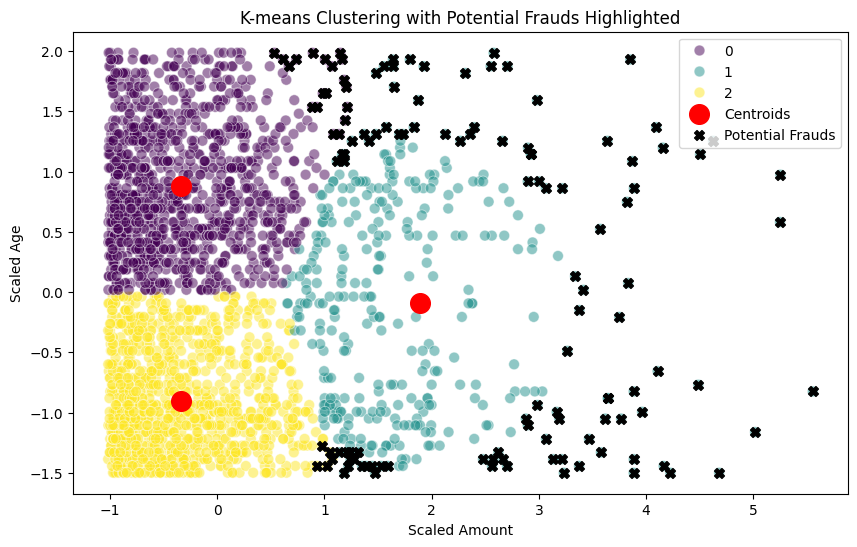


Number of potential frauds detected: 126


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
X = df[['TransactionAmount', 'CustomerAge']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels
distances = np.linalg.norm(X_scaled - kmeans.cluster_centers_[kmeans_labels], axis=1)
threshold = np.percentile(distances, 95)
df['Potential_Fraud'] = distances > threshold
frauds = df[df['Potential_Fraud']]
non_frauds = df[~df['Potential_Fraud']]

# Plot with frauds highlighted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=kmeans_labels, palette='viridis', s=60, alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', label='Centroids')
plt.scatter(X_scaled[distances > threshold, 0], X_scaled[distances > threshold, 1],
            color='black', s=50, label='Potential Frauds', marker='X')
plt.title('K-means Clustering with Potential Frauds Highlighted')
plt.xlabel('Scaled Amount')
plt.ylabel('Scaled Age')
plt.legend()
plt.show()

print(f"\nNumber of potential frauds detected: {len(frauds)}")

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[['TransactionAmount', 'CustomerAge']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['KMeans'] = kmeans.fit_predict(X_scaled)

distances = np.linalg.norm(X_scaled - kmeans.cluster_centers_[df['KMeans']], axis=1)

threshold = np.percentile(distances, 95)
df['Potential_Fraud'] = distances > threshold

frauds = df[df['Potential_Fraud']]
non_frauds = df[~df['Potential_Fraud']]

fig = px.scatter(
    df,x=X_scaled[:, 0], y=X_scaled[:, 1],color='KMeans',  hover_data=['TransactionAmount', 'CustomerAge', 'Potential_Fraud'],
    title="K-means Clustering with Potential Frauds Highlighted",labels={'x': 'Scaled Transaction Amount', 'y': 'Scaled Customer Age'},
    color_continuous_scale='Viridis',
)

fig.add_scatter(
    x=kmeans.cluster_centers_[:, 0],
    y=kmeans.cluster_centers_[:, 1],
    mode='markers',
    marker=dict(color='red', size=12, symbol='star'),
    name="Centroids"
)
